# Exploring the momentum/MACD features

Builds the 8-feature panel (`(date, ticker, feature)`) across the 26-ticker ETF universe using `trading_strategies.features`, then looks at distributions, cross-ticker agreement, and time series for a couple of names.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from trading_strategies.features import MACD_PAIRS, MOMENTUM_LOOKBACKS, compute_all_features

pd.set_option("display.max_columns", None)

## Load raw prices and build the feature panel

In [2]:
raw = pd.read_parquet("../data/raw.parquet")
raw = raw.sort_values(["ticker", "date"]).set_index("date")
raw.groupby("ticker").size().sort_values()

ticker
BND    4708
USO    4708
UNG    4708
TLT    4708
TIP    4708
SPY    4708
SLV    4708
SHY    4708
QQQ    4708
LQD    4708
IWM    4708
IEF    4708
HYG    4708
GLD    4708
FXY    4708
FXE    4708
FXC    4708
FXB    4708
FXA    4708
EWJ    4708
EFA    4708
EEM    4708
DBC    4708
DBA    4708
UUP    4708
VGK    4708
dtype: int64

In [3]:
def _features_for_one_ticker(group: pd.DataFrame) -> pd.DataFrame:
    return compute_all_features(group["close"], macd_phi=False)


panel = raw.groupby("ticker", group_keys=True).apply(_features_for_one_ticker)
panel.index.names = ["ticker", "date"]
panel = panel.reorder_levels(["date", "ticker"]).sort_index()

print(panel.shape)
panel.tail()

(122408, 8)


mom_1    mom_21    mom_63   mom_126   mom_252  \
date       ticker                                                     
2025-12-31 TLT    -1.460519 -0.729261 -0.555398 -0.078193  0.007921   
           UNG    -1.770503 -1.228727 -0.346121 -0.533527 -0.413140   
           USO    -0.523770 -0.370916 -0.442117 -0.496717 -0.259226   
           UUP    -0.109096 -1.363996 -0.320368  0.087803 -0.736627   
           VGK    -0.592330  0.962962  0.646867  0.938171  2.474767   

                   macd_8_24  macd_16_48  macd_32_96  
date       ticker                                     
2025-12-31 TLT     -0.829579   -1.103011   -0.461939  
           UNG     -0.935084   -0.689464   -0.425096  
           USO     -0.357075   -1.175428   -1.948660  
           UUP     -2.560488   -1.587962   -0.320555  
           VGK      1.624853    2.355911    1.840021

## Sanity checks: NaN warm-up period and distribution per feature

The longest lookback (252d momentum) plus the 252d winsorize window means each ticker needs ~500 trading days before every feature is populated.

In [4]:
nan_counts = panel.isna().sum()
first_fully_valid_date = panel.dropna().index.get_level_values("date").min()
print("NaNs per feature:\n", nan_counts)
print("\nFirst fully-valid date across all tickers/features:", first_fully_valid_date)

NaNs per feature:
 mom_1         1560
mom_21        1560
mom_63        1638
mom_126       3276
mom_252       6552
macd_8_24     8138
macd_16_48    8138
macd_32_96    8996
dtype: int64

First fully-valid date across all tickers/features: 2008-08-29 00:00:00


In [5]:
panel.dropna().describe()

,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
count,113412.000000,113412.000000,113412.000000,113412.000000,113412.000000,113412.000000,113412.000000,113412.000000
mean,0.003053,0.040075,0.077528,0.103064,0.105202,0.066542,0.124135,0.204144
std,0.973634,0.933376,0.943132,0.975324,1.039749,1.070824,1.228021,1.692867
min,-5.280816,-3.956142,-3.501349,-3.479993,-3.928949,-4.008153,-4.501683,-10.849462
25%,-0.593540,-0.586795,-0.570644,-0.582215,-0.630842,-0.718731,-0.913726,-1.041876
50%,0.036121,0.071286,0.104841,0.108826,0.078806,0.118090,0.196396,0.254031
75%,0.631315,0.690935,0.737019,0.789118,0.791921,0.864232,1.125684,1.310509
max,4.618221,4.036534,3.927032,4.769100,5.282716,4.431357,5.870867,10.369670


## Feature correlation

Are the 5 momentum lookbacks and 3 MACD variants actually adding independent information, or mostly redundant?

,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
mom_1,1.000000,0.232399,0.145131,0.108213,0.073519,0.115397,0.056268,0.027416
mom_21,0.232399,1.000000,0.611639,0.447824,0.315927,0.875978,0.743095,0.379685
mom_63,0.145131,0.611639,1.000000,0.703767,0.476200,0.611484,0.806294,0.691922
mom_126,0.108213,0.447824,0.703767,1.000000,0.662743,0.455240,0.679622,0.795049
mom_252,0.073519,0.315927,0.476200,0.662743,1.000000,0.335407,0.526915,0.707422
macd_8_24,0.115397,0.875978,0.611484,0.455240,0.335407,1.000000,0.837623,0.439743
macd_16_48,0.056268,0.743095,0.806294,0.679622,0.526915,0.837623,1.000000,0.780427
macd_32_96,0.027416,0.379685,0.691922,0.795049,0.707422,0.439743,0.780427,1.000000


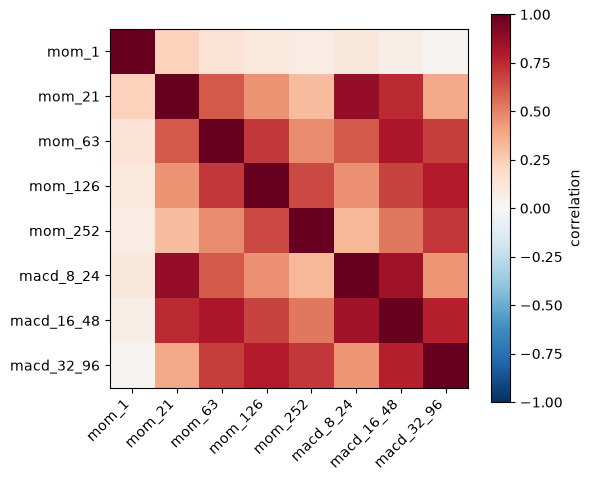

In [6]:
corr = panel.dropna().corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(im, ax=ax, label="correlation")
fig.tight_layout()
corr

## Time series for one ticker

Pick a ticker and eyeball the feature time series against price, to check the features move sensibly with visible trends.

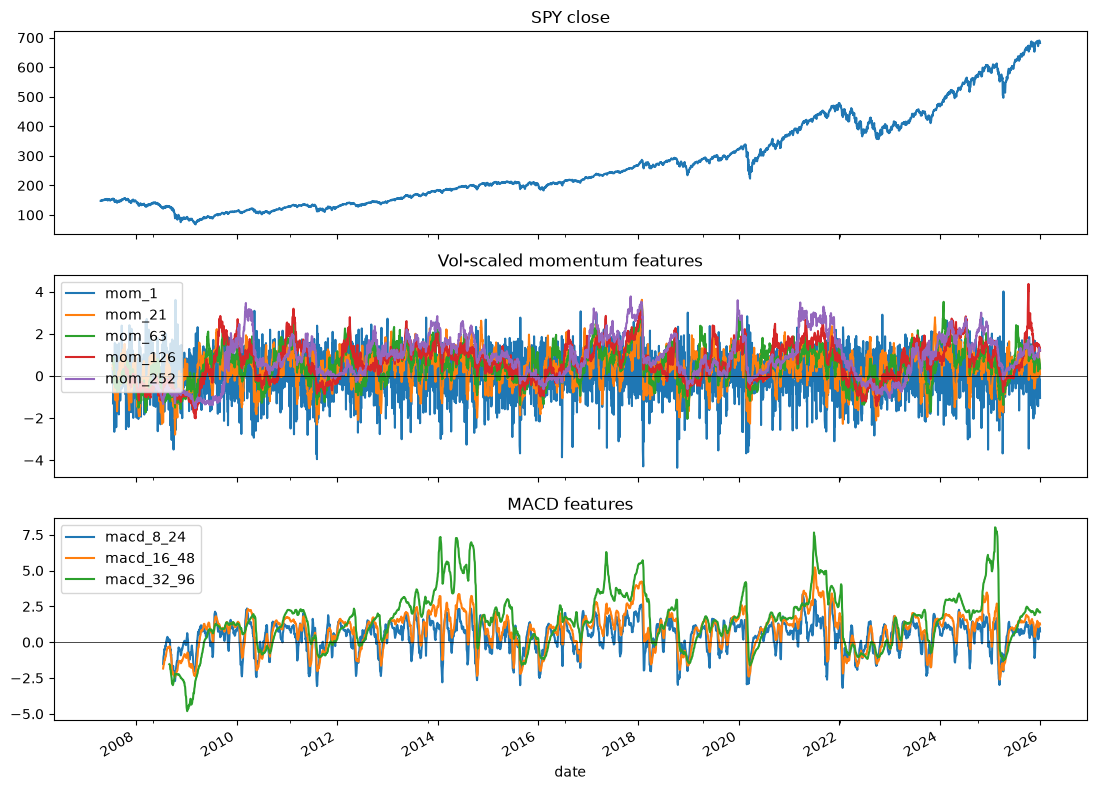

In [7]:
ticker = "SPY"
ticker_features = panel.xs(ticker, level="ticker")
ticker_close = raw.loc[raw["ticker"] == ticker, "close"]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(ticker_close.index, ticker_close.values)
axes[0].set_title(f"{ticker} close")

mom_cols = [f"mom_{lb}" for lb in MOMENTUM_LOOKBACKS]
ticker_features[mom_cols].plot(ax=axes[1])
axes[1].set_title("Vol-scaled momentum features")
axes[1].axhline(0, color="black", linewidth=0.5)

macd_cols = [f"macd_{short}_{long}" for short, long in MACD_PAIRS]
ticker_features[macd_cols].plot(ax=axes[2])
axes[2].set_title("MACD features")
axes[2].axhline(0, color="black", linewidth=0.5)

fig.tight_layout()

## Winsorize halflife sensitivity

`winsorize` clips each feature to +/- 5 EWM std around its EWM mean, with `halflife=31` (the default was 252; the sensitivity check below showed clipping barely happens at any halflife tested, so 31 was chosen instead). Build the *raw* (unwinsorized) features once, then apply `winsorize` at a few different halflives on top, and compare:

1. an overlay plot of the clipped series at each halflife against the raw series
2. how often each halflife actually clips anything
3. how correlated the resulting series are across halflives (if ~1.0, the choice barely matters)

In [8]:
from trading_strategies.features import (
    daily_returns,
    ewm_vol,
    macd_indicator,
    vol_scaled_momentum,
    winsorize,
)

HALFLIVES = [31, 63, 126, 252, 504]
BASELINE_HALFLIFE = 31


def _raw_features_for_one_ticker(group: pd.DataFrame) -> pd.DataFrame:
    close = group["close"]
    returns = daily_returns(close)
    vol = ewm_vol(returns)
    feats = {
        f"mom_{lookback}": vol_scaled_momentum(close, lookback, vol)
        for lookback in MOMENTUM_LOOKBACKS
    }
    feats.update(
        {f"macd_{short}_{long}": macd_indicator(close, short, long) for short, long in MACD_PAIRS}
    )
    return pd.DataFrame(feats, index=close.index)


# Kept as (ticker, date) here (not reordered like `panel`) so a plain
# groupby(level="ticker") is enough to winsorize each ticker's series
# independently -- reordering to (date, ticker) first would let a naive
# `.apply` see other tickers' feature vector as a "row" and corrupt the EWM.
raw_panel = raw.groupby("ticker", group_keys=True).apply(_raw_features_for_one_ticker)
raw_panel.index.names = ["ticker", "date"]

winsorized_by_halflife = {
    hl: raw_panel.groupby(level="ticker", group_keys=False).apply(
        lambda g, hl=hl: g.apply(lambda col: winsorize(col, halflife=hl))
    )
    for hl in HALFLIVES
}

print(raw_panel.shape)

(122408, 8)


### 1. Overlay: raw vs. clipped at each halflife, a random sample of tickers

A 6x8 grid (all tickers, all features) is unreadable. Sample 6 tickers at random (2 rows x 3 cols), one grid figure per feature.

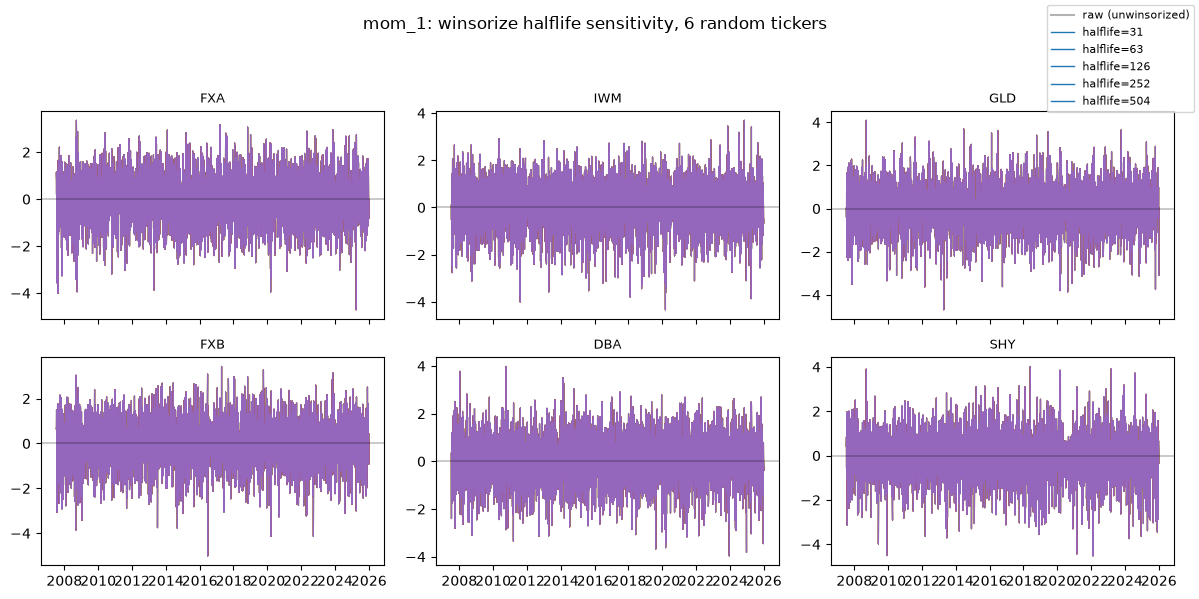

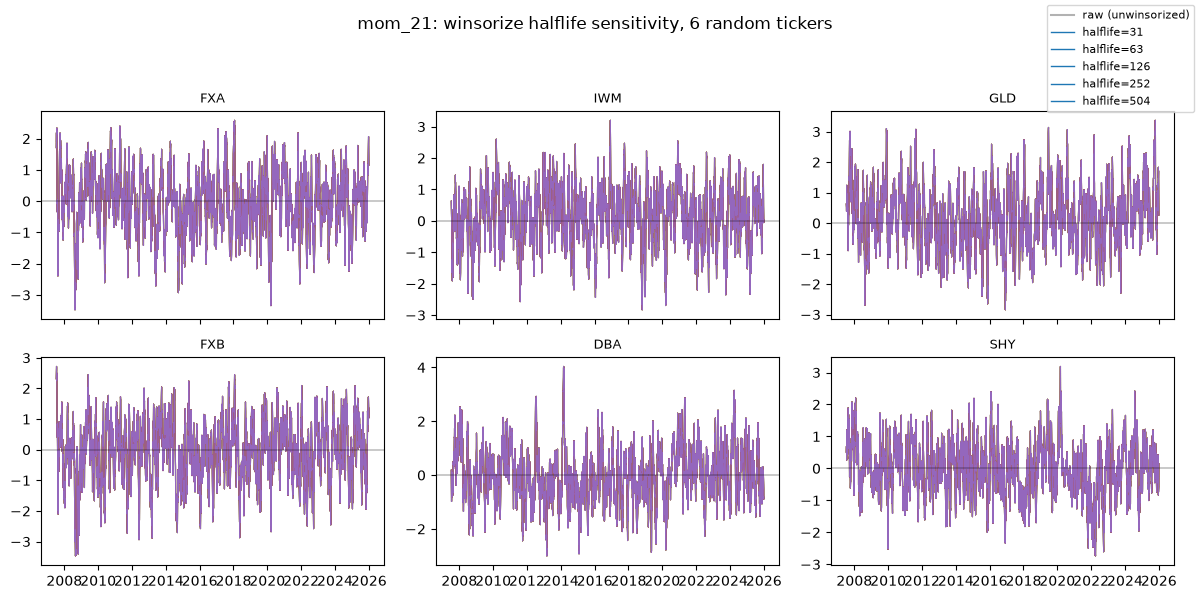

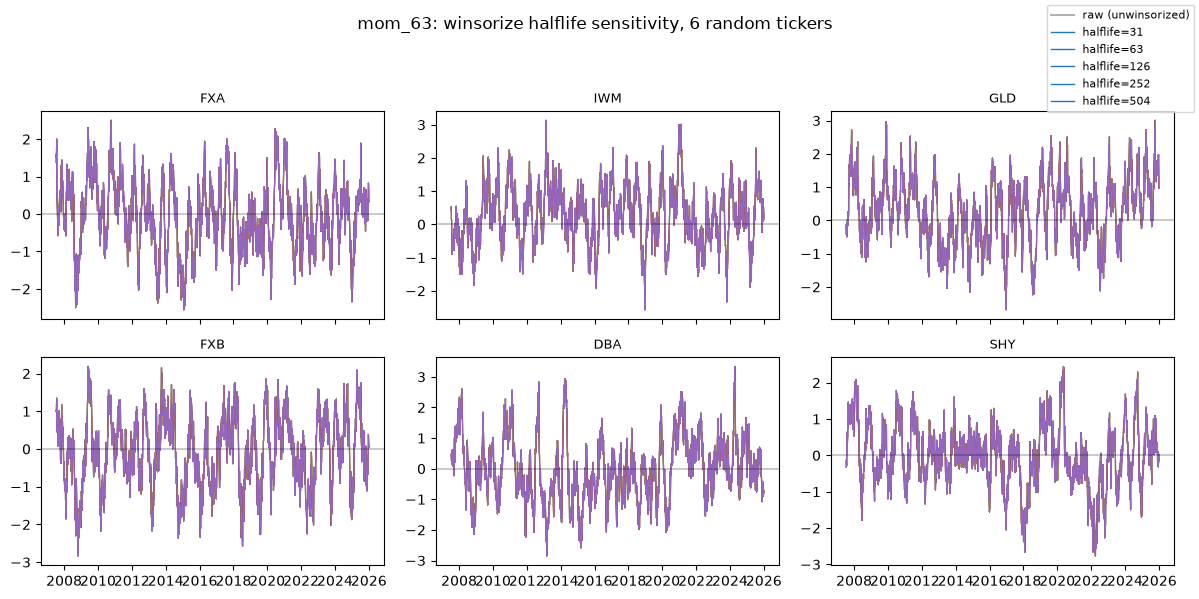

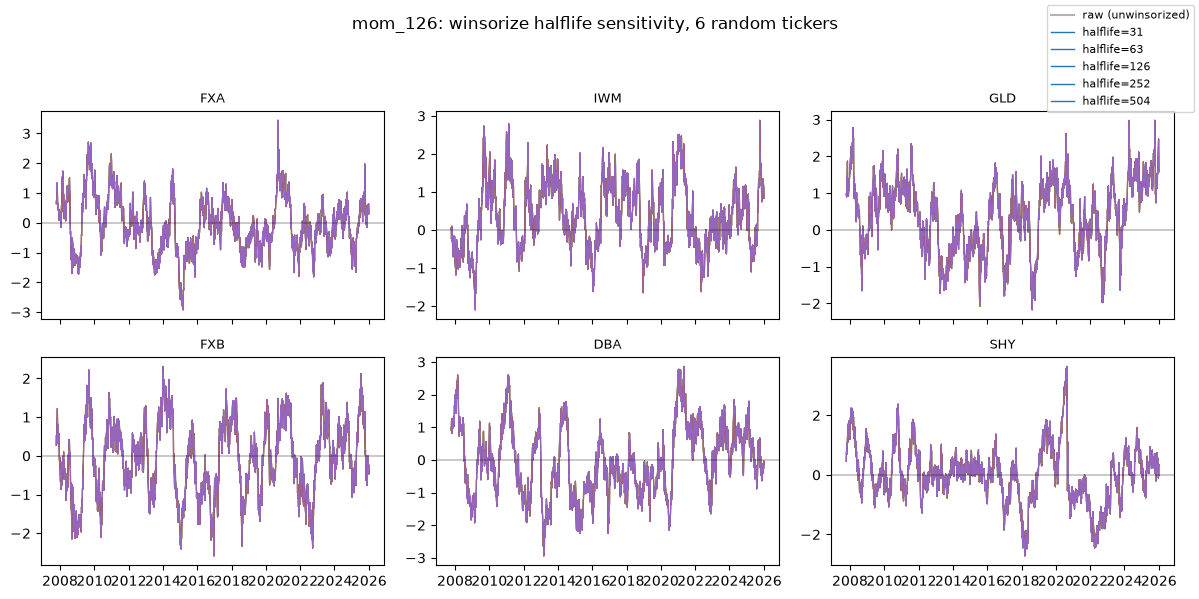

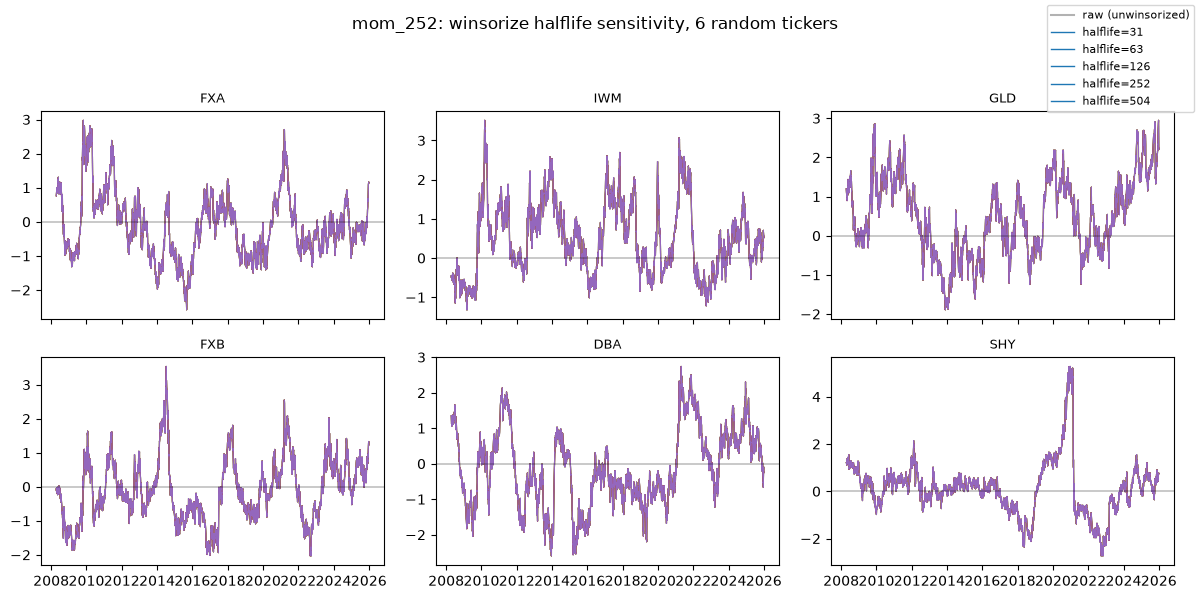

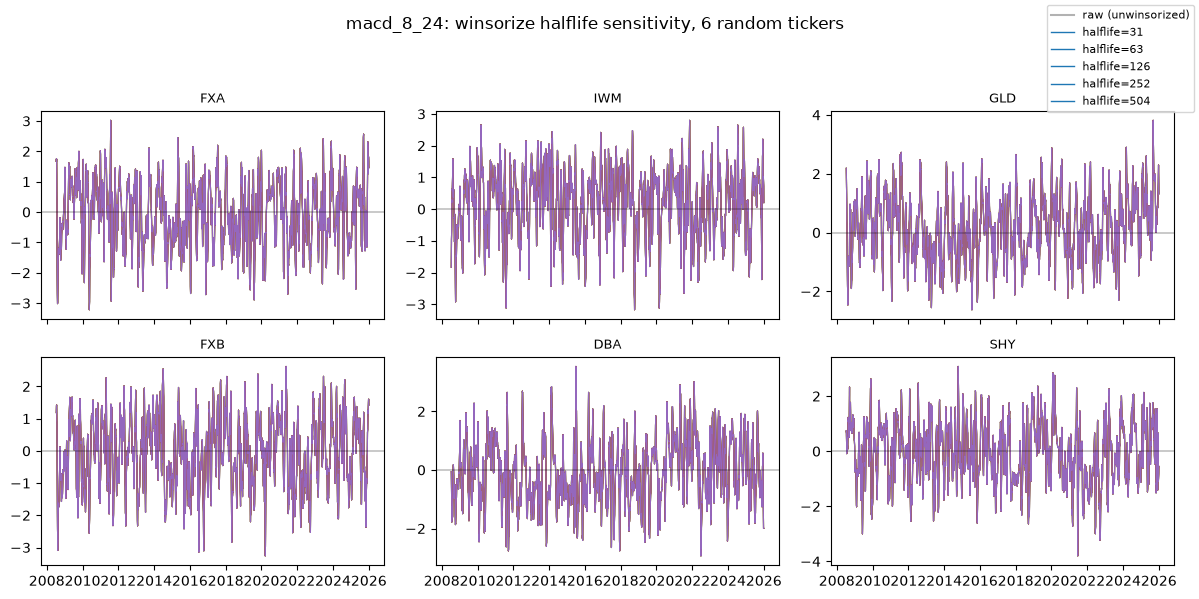

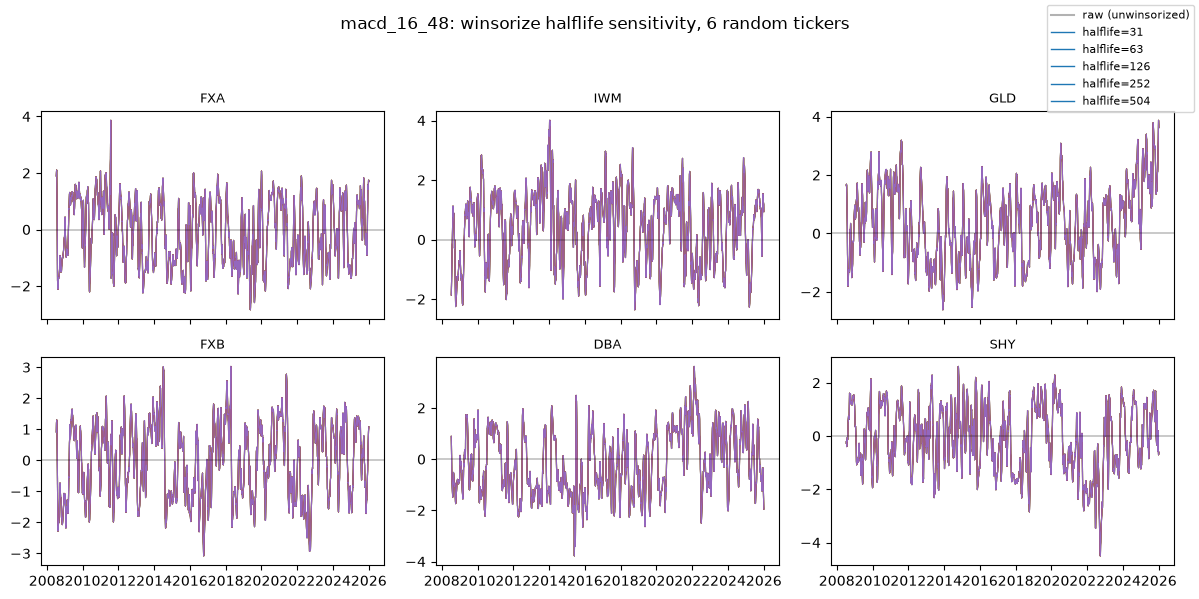

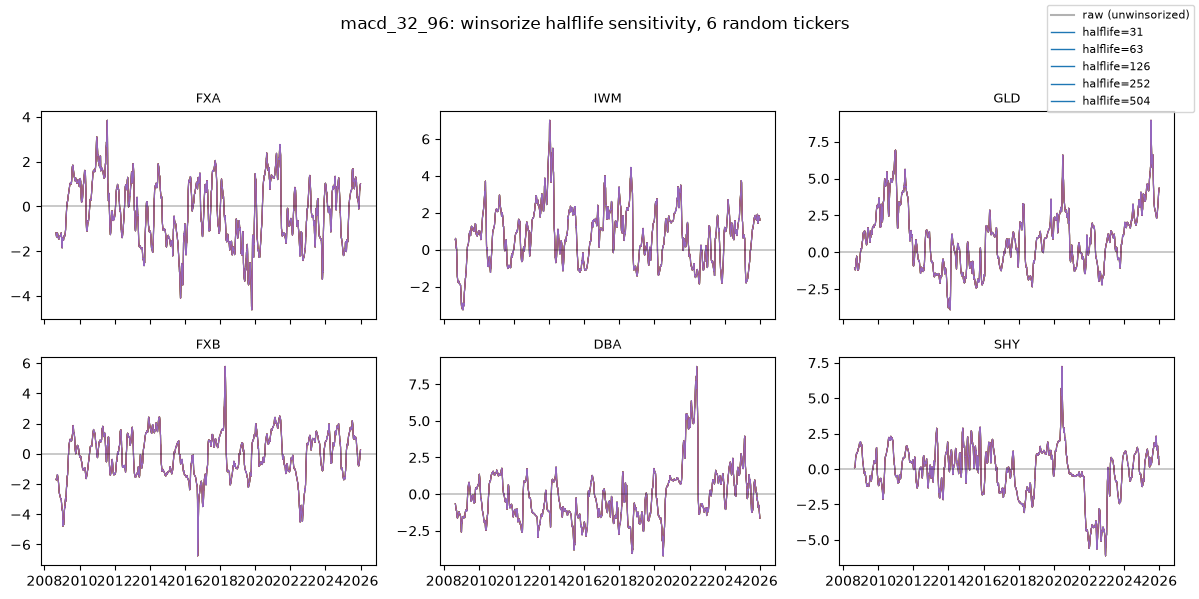

In [9]:
import numpy as np
from matplotlib.lines import Line2D

all_tickers = sorted(raw_panel.index.get_level_values("ticker").unique())
features = list(raw_panel.columns)

SAMPLE_SIZE = 6
sample_tickers = list(np.random.default_rng(0).choice(all_tickers, size=SAMPLE_SIZE, replace=False))
nrows, ncols = 2, 3

legend_handles = [Line2D([], [], color="black", alpha=0.3, label="raw (unwinsorized)")] + [
    Line2D([], [], linewidth=1, label=f"halflife={hl}") for hl in HALFLIVES
]

for feature in features:
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharex=True)
    axes_flat = axes.flatten()

    for ax, ticker in zip(axes_flat, sample_tickers, strict=True):
        raw_series = raw_panel.xs(ticker, level="ticker")[feature]
        ax.plot(raw_series.index, raw_series.values, color="black", alpha=0.3, linewidth=0.8)

        for hl in HALFLIVES:
            clipped_series = winsorized_by_halflife[hl].xs(ticker, level="ticker")[feature]
            ax.plot(clipped_series.index, clipped_series.values, linewidth=0.8)

        ax.axhline(0, color="black", linewidth=0.3)
        ax.set_title(ticker, fontsize=9)

    fig.suptitle(f"{feature}: winsorize halflife sensitivity, {SAMPLE_SIZE} random tickers")
    fig.legend(handles=legend_handles, loc="upper right", fontsize=8)
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))

### 2. How often does each halflife actually clip anything?

In [10]:
# `.clip()` returns the input value unchanged (bit-for-bit) when it doesn't
# bind, so an exact `!=` is a safe way to detect "this point was clipped" --
# restricted to points where the raw value is valid (NaNs propagate through
# winsorize as NaN, and NaN != NaN would otherwise be miscounted as "clipped").
valid = raw_panel.notna()

clip_rates = pd.DataFrame(
    {
        hl: ((winsorized_by_halflife[hl] != raw_panel) & valid).sum() / valid.sum()
        for hl in HALFLIVES
    }
)
clip_rates.columns.name = "halflife"
(clip_rates * 100).round(3)

halflife,31,63,126,252,504
mom_1,0.0,0.001,0.001,0.002,0.002
mom_21,0.0,0.000,0.000,0.000,0.000
mom_63,0.0,0.000,0.000,0.000,0.000
mom_126,0.0,0.000,0.000,0.000,0.000
mom_252,0.0,0.001,0.009,0.016,0.001
macd_8_24,0.0,0.000,0.000,0.000,0.000
macd_16_48,0.0,0.000,0.000,0.000,0.000
macd_32_96,0.0,0.001,0.002,0.000,0.000


### 3. Correlation between halflife variants

For each feature, correlate the `halflife=31` (current default) output against every other halflife, pooling all tickers and dates together. Close to 1.0 means the halflife choice barely matters in practice.

In [11]:
baseline = winsorized_by_halflife[BASELINE_HALFLIFE]

sensitivity_rows = {}
for hl in HALFLIVES:
    if hl == BASELINE_HALFLIFE:
        continue
    other = winsorized_by_halflife[hl]
    row = {}
    for feature in raw_panel.columns:
        both_valid = baseline[feature].notna() & other[feature].notna()
        row[feature] = baseline.loc[both_valid, feature].corr(other.loc[both_valid, feature])
    sensitivity_rows[f"{BASELINE_HALFLIFE} vs {hl}"] = row

sensitivity_corr = pd.DataFrame(sensitivity_rows).T
sensitivity_corr.round(4)

,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
31 vs 63,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
31 vs 126,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
31 vs 252,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
31 vs 504,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
